In [1]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt


c:\Users\sjs93\anaconda3\envs\resp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
elec_noise_freq=60
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3130311/ paper suggested these min and max cut offs
min_freq=30
max_freq=1000
resample_rate=1000

In [3]:
datapath = r"E:\heart_rate_recording\20250107_164636_hear_rate_mouse1.rec\20250107_164636_hear_rate_mouse1.rec"
 #se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'trodes')
print(recording)
# removes the noise from the reccording notch filter removes a given freq. 
recording = sp.notch_filter(recording, freq=elec_noise_freq)
# sets filter for a min and max cutoff
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
# resamples transforms data into sampling rates HZ
recording = sp.resample(recording, resample_rate=resample_rate)

SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 6,599,122 samples 
                                329.96s (5.50 minutes) - int16 dtype - 402.78 MiB
  file_path: E:\heart_rate_recording\20250107_164636_hear_rate_mouse1.rec\20250107_164636_hear_rate_mouse1.rec


In [4]:
# creates a numpy array of the time and channels 
#recoirding = class object that has the meta data and data 
#get_traces is the function that gets me just the data 
traces = recording.get_traces()

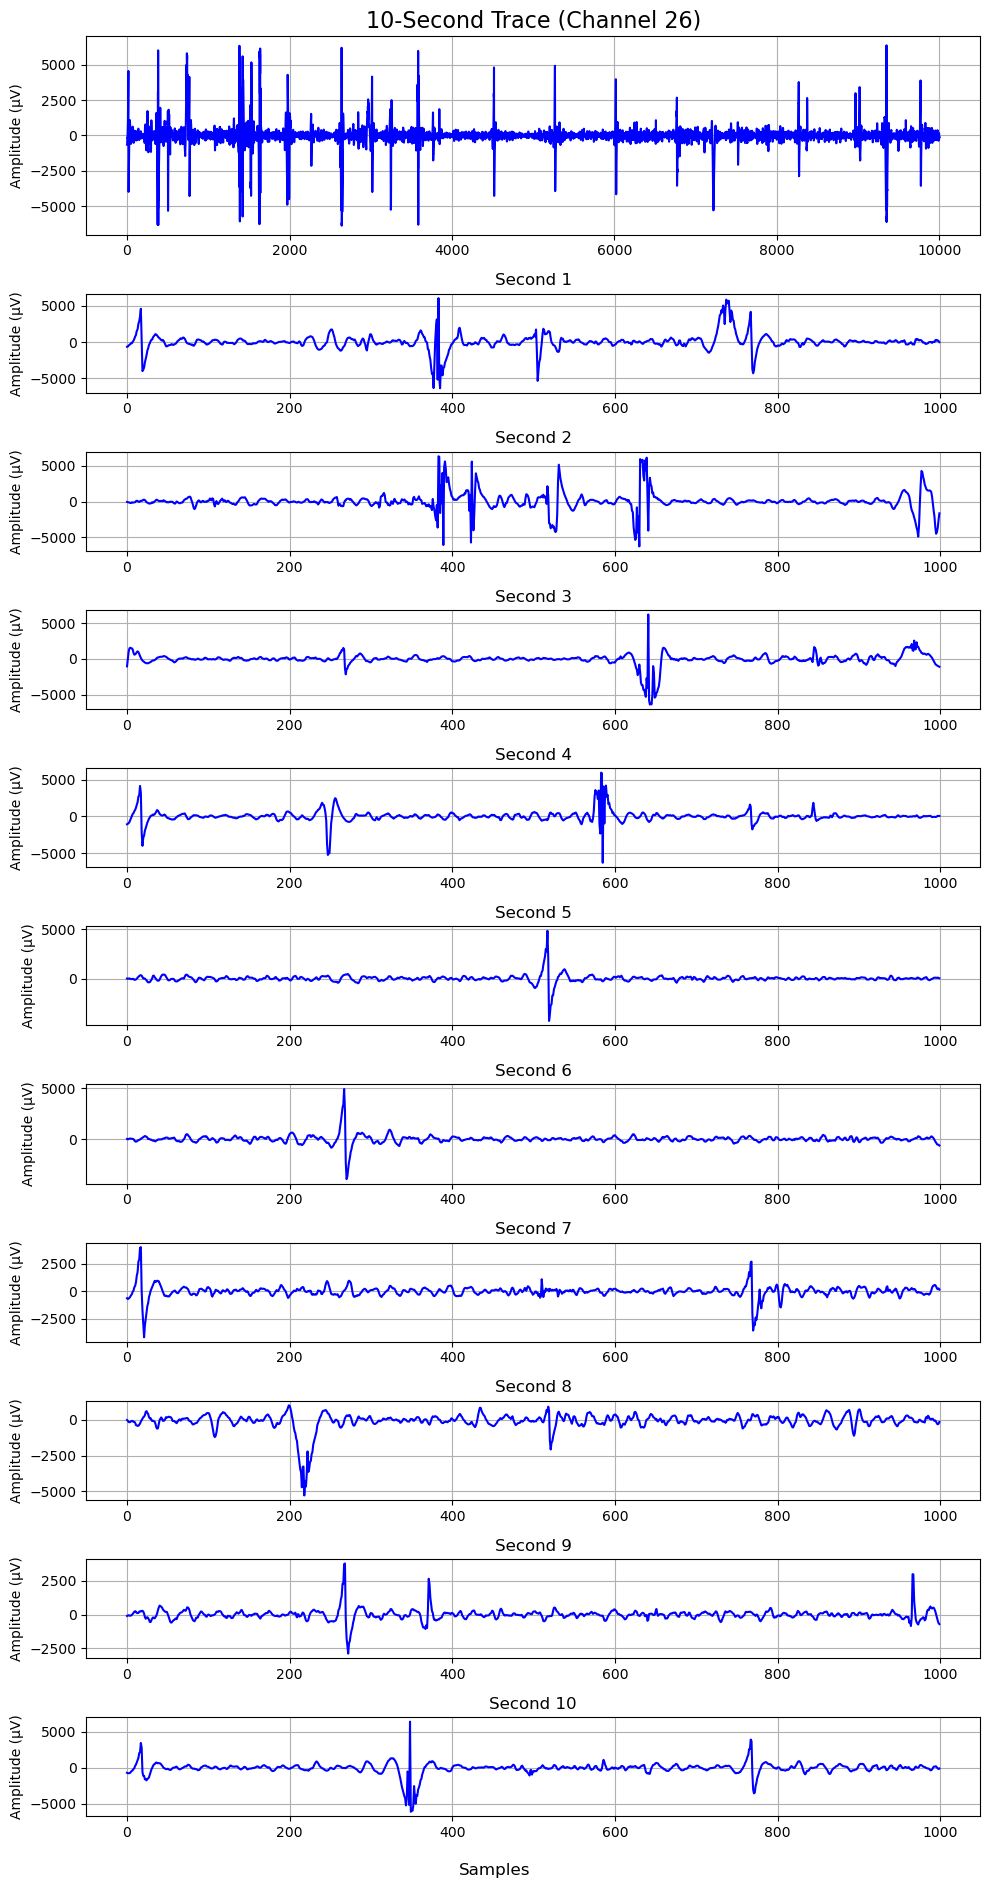

In [5]:
# Parameters
elec_noise_freq = 60
min_freq = 30
max_freq = 1000
resample_rate = 1000
datapath = r"E:\heart_rate_recording\20250107_164636_hear_rate_mouse1.rec\20250107_164636_hear_rate_mouse1.rec"
ref_channel = 21
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]

# Load and preprocess the recording
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
traces = recording.get_traces()

# Define chunking parameters
samples_per_second = resample_rate
samples_per_10sec = 10 * samples_per_second
samples_per_1sec = samples_per_second

# Select the start of the chunk (e.g., first 10 seconds of recording)
start_idx = 0
end_idx = start_idx + samples_per_10sec

# Extract the 10-second trace for a specific channel (e.g., channel 26)
channel = 26
ten_sec_trace = traces[start_idx:end_idx, channel]

# Convert data to microvolts if necessary
# Assuming the data is in its raw format and needs scaling
scaling_factor = 0.195  # Example: conversion from ADC units to µV
ten_sec_trace = ten_sec_trace * scaling_factor

# Create a figure with one large plot for the 10-second trace and subplots for 1-second chunks
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)  # 1 large plot + 10 smaller plots

# Plot the full 10-second trace at the top
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ten_sec_trace, color='b')
ax1.set_title(f"10-Second Trace (Channel {channel})", fontsize=16)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# Plot the 1-second subplots
for i in range(10):
    chunk_start = i * samples_per_1sec
    chunk_end = chunk_start + samples_per_1sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(ten_sec_trace[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid()

# Add a common x-axis label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()